In [163]:
# ============================================================
# ONE-CELL PIPELINE: Base (SDSS/PS1/ZTF) + SuperCOSMOS (SSS) -> Total LC
# Output: df_total with columns: OBJID, band (u/g/r/i/z), time, mag, magerr, survey
# ============================================================

import warnings
import numpy as np
import pandas as pd

from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

def serc_to_sdss_lc(
    df_lc: pd.DataFrame,
    z_col: str = "z",
    objid_col: str = "OBJID",
    band_col: str = "band",
    mag_col: str = "SMAG",
    out_mag_col: str = "MAG_SDSS",
    out_band_col: str = "band_sdss",
    template_path: str = "../stripe82_quasars/vdb_qso_template.txt",
) -> pd.DataFrame:
    """
    Convert SERC B_J, R, I magnitudes in a *long-form* light-curve table (df_lc)
    to SDSS-like g, r, i using a quasar template and bandpass curves.

    Expected df_lc columns (minimum):
      - OBJID, z, band, SMAG
    where band ∈ {'B_J','R','I'} for SERC rows you want converted.

    Parameters
    ----------
    df_lc : pandas.DataFrame
        Long-form light curve table (one row per measurement).
    template_path : str
        Path to the quasar template file (CDS ASCII).
    out_mag_col : str
        Name of output SDSS magnitude column (single column).
    out_band_col : str
        Name of output SDSS band label column.

    Returns
    -------
    out : pandas.DataFrame
        Copy of df_lc with SDSS-converted magnitudes attached.
        - out[out_mag_col] contains the converted SDSS magnitude for rows with band in {'B_J','R','I'}.
        - out[out_band_col] contains {'g','r','i'} correspondingly.
    """

    # Read SDSS g/r/i bandpasses and add to bands (expects files named SLOAN_SDSS.g, SLOAN_SDSS.r, SLOAN_SDSS.i)
    bp_files = {'g': 'SLOAN_SDSS.g.dat', 'r': 'SLOAN_SDSS.r.dat', 'i': 'SLOAN_SDSS.i.dat', 'BJ': 'serc-j.txt', 'R': 'serc-r.txt', 'I': 'serc-i.txt'}
    bands = {}
    for b, fname in bp_files.items():
        tbl_bp = Table.read(fname, format='ascii')
        # take first two columns as wavelength and throughput
        wcol, tcol = tbl_bp.colnames[:2]
        w = np.asarray(tbl_bp[wcol], dtype=float)
        T = np.asarray(tbl_bp[tcol], dtype=float)
        # if the wavelength column has a unit, convert to Angstroms
        try:
            unit = tbl_bp[wcol].unit
            if unit is not None:
                w = (w * unit).to('angstrom').value
        except Exception:
            pass
        bands[b] = (w, T)

    required = {objid_col, z_col, band_col, mag_col}
    missing = required - set(df_lc.columns)
    if missing:
        raise ValueError(f"df_lc is missing required columns: {sorted(missing)}")

    # ---- Load quasar template ----
    tbl = Table.read(template_path, format="ascii.cds")
    wave_rest = np.asarray(tbl["Wave"], dtype=float)   # Angstrom
    flux_rest = np.asarray(tbl["FluxD"], dtype=float)  # relative flux density

    # AB magnitude integrals
    c = 2.99792458e18  # Å/s
    f0 = 3.631e-20     # erg/s/cm^2/Hz

    def abmag(w_obs, f_obs, wf, tf):
        # integrate only on overlap region for numerical stability
        mask = (wf > w_obs.min()) & (wf < w_obs.max())
        if mask.sum() < 5:
            return np.nan
        lam = wf[mask]
        T = tf[mask]
        f_lam = np.interp(lam, w_obs, f_obs)
        num = np.trapz(f_lam * T, lam)
        den = np.trapz(T * c / lam**2, lam)
        if (num <= 0) or (den <= 0):
            return np.nan
        return -2.5 * np.log10(num / den / f0)

    # ---- Precompute template-based offsets per OBJID (via z) ----
    # One z per OBJID (if multiple, first is used)
    z_per_obj = df_lc.groupby(objid_col, sort=False)[z_col].first()

    # We will compute:
    #   dg = m_g(z) - m_BJ(z)
    #   dr = m_r(z) - m_R(z)
    #   di = m_i(z) - m_I(z)
    # so:
    #   g_sdss = B_J + dg
    #   r_sdss = R   + dr
    #   i_sdss = I   + di
    uniq_z = pd.unique(z_per_obj.to_numpy())

    # cache m(z, band) only for the needed 6 bands
    m_cache = {}
    for z in uniq_z:
        if not np.isfinite(z):
            continue
        lam_obs = wave_rest * (1.0 + z)
        f_obs = flux_rest / (1.0 + z)

        # compute AB mags through each filter curve
        mz = {}
        for key in ("BJ", "R", "I", "g", "r", "i"):
            wf, tf = bands[key]
            mz[key] = abmag(lam_obs, f_obs, np.asarray(wf, dtype=float), np.asarray(tf, dtype=float))

        # if any required is nan, store nans
        if any(np.isnan(mz[k]) for k in ("BJ", "R", "I", "g", "r", "i")):
            m_cache[z] = (np.nan, np.nan, np.nan)
        else:
            dg = mz["g"] - mz["BJ"]
            dr = mz["r"] - mz["R"]
            di = mz["i"] - mz["I"]
            m_cache[z] = (dg, dr, di)

    # Build per-OBJID offset table
    offsets = pd.DataFrame({objid_col: z_per_obj.index, z_col: z_per_obj.values})
    # map z->(dg,dr,di)
    dg_arr = np.empty(len(offsets), dtype=float)
    dr_arr = np.empty(len(offsets), dtype=float)
    di_arr = np.empty(len(offsets), dtype=float)
    dg_arr.fill(np.nan); dr_arr.fill(np.nan); di_arr.fill(np.nan)

    z_vals = offsets[z_col].to_numpy()
    for i, z in enumerate(z_vals):
        if np.isfinite(z) and (z in m_cache):
            dg_arr[i], dr_arr[i], di_arr[i] = m_cache[z]

    offsets["dg"] = dg_arr
    offsets["dr"] = dr_arr
    offsets["di"] = di_arr

    # ---- Merge offsets back onto df_lc ----
    out = df_lc.copy()
    out = out.merge(offsets[[objid_col, "dg", "dr", "di"]], on=objid_col, how="left")

    # ---- Apply conversion row-wise by band (vectorized) ----
    # Initialize outputs
    out[out_mag_col] = np.nan
    out[out_band_col] = None

    band_vals = out[band_col].astype(str).to_numpy()
    mags = pd.to_numeric(out[mag_col], errors="coerce").to_numpy()

    # masks for SERC bands
    m_bj = band_vals == "B_J"
    m_r  = band_vals == "R"
    m_i  = band_vals == "I"

    # convert only where offsets exist and magnitudes are finite
    ok_bj = m_bj & np.isfinite(mags) & np.isfinite(out["dg"].to_numpy())
    ok_r  = m_r  & np.isfinite(mags) & np.isfinite(out["dr"].to_numpy())
    ok_i  = m_i  & np.isfinite(mags) & np.isfinite(out["di"].to_numpy())

    out.loc[ok_bj, out_mag_col] = mags[ok_bj] + out.loc[ok_bj, "dg"].to_numpy()
    out.loc[ok_r,  out_mag_col] = mags[ok_r]  + out.loc[ok_r,  "dr"].to_numpy()
    out.loc[ok_i,  out_mag_col] = mags[ok_i]  + out.loc[ok_i,  "di"].to_numpy()

    out.loc[ok_bj, out_band_col] = "g"
    out.loc[ok_r,  out_band_col] = "r"
    out.loc[ok_i,  out_band_col] = "i"

    # drop intermediate offsets unless you want to keep them
    out = out.drop(columns=["dg", "dr", "di"], errors="ignore")

    return out



# -----------------------------
# 0) YOUR BASE LC LOADER (as-is)
# -----------------------------

filters = {"u": 0, "g": 1, "r": 2, "i": 3, "z": 4, "y": 5}  # SDSS-like hardcoded order
bands_sdss = ["u", "g", "r", "i", "z"]

def concat_light_curves_df(
    filter_object_ids=None,
    skip=None,
    N=None,
    data_dir="data/S82",
):
    cat = pd.read_parquet(f"{data_dir}/Catalog.parquet").set_index("idx")

    sdss = pd.read_parquet(f"{data_dir}/dr16s82_sdssLCRaw.parquet")
    ps1 = pd.read_parquet(f"{data_dir}/dr16s82_ps1LCRaw.parquet")
    ztf = pd.read_parquet(f"{data_dir}/dr16s82_ZuberLCRaw.parquet")

    sdss = sdss.loc[sdss["mjd"].notna()]

    sdss_objids = pd.Index(sdss["objectId"].unique())
    if filter_object_ids is not None:
        sdss_objids = sdss_objids.intersection(pd.Index(filter_object_ids))

    cat = cat.loc[cat["objectId"].isin(sdss_objids)]
    if skip is not None:
        cat = cat.iloc[skip:]
    if N is not None:
        cat = cat.iloc[:N]

    if len(cat) == 0:
        return pd.DataFrame(columns=["objectId", "band", "time", "mag", "magerr", "survey"])

    cat_keys = cat.reset_index(drop=False).copy()
    cat_keys["ps1objID"] = pd.to_numeric(cat_keys["ps1objID"], errors="coerce").astype("Int64")

    offset_wide = pd.DataFrame(
        {
            "objectId": cat_keys["objectId"].values,
            "g": cat_keys["sdss_g_qg"].values - cat_keys["ps1_g_qg"].values,
            "r": cat_keys["sdss_r_qg"].values - cat_keys["ps1_r_qg"].values,
            "i": cat_keys["sdss_i_qg"].values - cat_keys["ps1_i_qg"].values,
            "z": cat_keys["sdss_z_qg"].values - cat_keys["ps1_z_qg"].values,
        }
    )
    offset_long = offset_wide.melt(id_vars=["objectId"], var_name="band", value_name="offset")
    u_offsets = pd.DataFrame({"objectId": cat_keys["objectId"].values, "band": "u", "offset": 0.0})
    offset_long = pd.concat([offset_long, u_offsets], ignore_index=True)
    offset_long["offset"] = pd.to_numeric(offset_long["offset"], errors="coerce").fillna(0.0)

    band_map = pd.DataFrame({"band": bands_sdss, "filterID": [filters[b] for b in bands_sdss]})

    sdss_df = (
        sdss.loc[sdss["objectId"].isin(cat_keys["objectId"])]
        .merge(band_map, on="filterID", how="inner")
        .loc[:, ["objectId", "band", "mjd", "psMag", "psMagErr_p3"]]
        .rename(columns={"mjd": "time", "psMag": "mag", "psMagErr_p3": "magerr"})
    )
    sdss_df["survey"] = "sdss"

    ps1_df = (
        ps1.merge(cat_keys.loc[:, ["ps1objID", "objectId"]], on="ps1objID", how="inner")
        .merge(band_map, on="filterID", how="inner")
        .loc[:, ["objectId", "band", "obsTime", "psfMag", "psfMagErr_p3"]]
        .rename(columns={"obsTime": "time", "psfMag": "mag", "psfMagErr_p3": "magerr"})
    )
    ps1_df["survey"] = "ps1"

    ztf_df = (
        ztf.merge(cat_keys.loc[:, ["ps1objID", "objectId"]], on="ps1objID", how="inner")
        .merge(band_map, on="filterID", how="inner")
        .loc[:, ["objectId", "band", "mjd", "mag", "magerr_p3"]]
        .rename(columns={"mjd": "time", "magerr_p3": "magerr"})
    )
    ztf_df["survey"] = "ztf"

    ps1_df = ps1_df.merge(offset_long, on=["objectId", "band"], how="left")
    ztf_df = ztf_df.merge(offset_long, on=["objectId", "band"], how="left")
    ps1_df["mag"] = ps1_df["mag"] + ps1_df["offset"].fillna(0.0)
    ztf_df["mag"] = ztf_df["mag"] + ztf_df["offset"].fillna(0.0)
    ps1_df = ps1_df.drop(columns=["offset"])
    ztf_df = ztf_df.drop(columns=["offset"])

    df = pd.concat([sdss_df, ps1_df, ztf_df], ignore_index=True)

    for col in ["time", "mag", "magerr"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.loc[df["time"].notna() & df["mag"].notna() & df["magerr"].notna()]
    df = df.loc[df["band"].isin(bands_sdss)]
    df = df.sort_values(["objectId", "band", "time"], kind="mergesort").reset_index(drop=True)
    return df


# -----------------------------
# 1) Load SSS raw + survey table
# -----------------------------

def load_sss_supercosmos_raw(wu_qso_parquet: str, survey_table_fits: str) -> pd.DataFrame:
    df = pd.read_parquet(wu_qso_parquet)
    df.columns = [c.upper() for c in df.columns]

    dat = fits.getdata(survey_table_fits)
    t = Table(dat)
    for name in t.colnames:
        if len(t[name].shape) > 1 and t[name].shape[1] == 1:
            t[name] = t[name].flatten()
    df_survey = t.to_pandas()
    df_survey.columns = [c.upper() for c in df_survey.columns]

    if "PLATEID" not in df.columns:
        raise KeyError("wu_qso_parquet missing PLATEID")
    df = df.merge(df_survey, on="PLATEID", how="left")

    # Standardize required columns
    # RA/DEC/MJD/SMAG are the key ones
    for cands, out in [
        (["RA", "ALPHA_J2000", "ALPHA"], "RA"),
        (["DEC", "DELTA_J2000", "DELTA"], "DEC"),
        (["MJD", "TIME", "T"], "MJD"),
        (["SMAG", "MAG", "MAGNITUDE"], "SMAG"),
    ]:
        if out not in df.columns:
            for c in cands:
                if c in df.columns:
                    df[out] = df[c]
                    break
    if "SMAG_ERR" not in df.columns:
        for c in ["SMAG_ERR", "MAGERR", "MAG_ERR", "ERR"]:
            if c in df.columns:
                df["SMAG_ERR"] = df[c]
                break
    if "SMAG_ERR" not in df.columns:
        df["SMAG_ERR"] = np.nan

    for c in ["RA", "DEC", "MJD", "SMAG", "SMAG_ERR"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["RA", "DEC", "MJD", "SMAG"]).reset_index(drop=True)

    # Native band label
    if "SURVEYNAME" in df.columns:
        df["BAND_NATIVE"] = df["SURVEYNAME"].astype(str)
    elif "BAND" in df.columns:
        df["BAND_NATIVE"] = df["BAND"].astype(str)
    else:
        df["BAND_NATIVE"] = np.nan

    def norm_native(x):
        s = str(x).strip().upper()
        if s in {"BJ", "B_J", "B-J", "B"} or ("BJ" in s) or ("B_J" in s):
            return "B_J"
        if s in {"R", "R59F", "RF"} or ("R59F" in s):
            return "R"
        if s in {"I", "IVN", "IN"} or ("IVN" in s):
            return "I"
        return s

    df["BAND_NATIVE"] = df["BAND_NATIVE"].map(norm_native)
    return df


# -----------------------------
# 2) Assign GROUP_ID to SSS by sky clustering
# -----------------------------

class _UnionFind:
    def __init__(self, n: int):
        self.parent = np.arange(n, dtype=int)
        self.rank = np.zeros(n, dtype=int)

    def find(self, a: int) -> int:
        while self.parent[a] != a:
            self.parent[a] = self.parent[self.parent[a]]
            a = self.parent[a]
        return a

    def union(self, a: int, b: int):
        ra = self.find(a)
        rb = self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        elif self.rank[ra] > self.rank[rb]:
            self.parent[rb] = ra
        else:
            self.parent[rb] = ra
            self.rank[ra] += 1

def assign_group_ids_by_sky(df: pd.DataFrame, radius_arcsec: float = 1.0) -> pd.DataFrame:
    out = df.copy().reset_index(drop=True)
    coords = SkyCoord(ra=out["RA"].to_numpy() * u.deg,
                      dec=out["DEC"].to_numpy() * u.deg,
                      frame="icrs")

    i1, i2, _, _ = coords.search_around_sky(coords, seplimit=radius_arcsec * u.arcsec)
    uf = _UnionFind(len(out))
    for a, b in zip(i1, i2):
        if int(a) != int(b):
            uf.union(int(a), int(b))

    roots = np.array([uf.find(i) for i in range(len(out))], dtype=int)
    _, gid = np.unique(roots, return_inverse=True)
    out["GROUP_ID"] = gid.astype(int)
    return out


# -----------------------------
# 3) Match GROUP_ID -> DR16Q (OBJID, z)
# -----------------------------

def build_gid_map_from_dr16q(
    df_with_groups: pd.DataFrame,
    dr16q_fits_path: str,
    max_sep_arcsec: float = 1.0,
    restrict_stripe82: bool = True,
    mag_lim_r: float = None,
    dr16q_ra_col: str = "ra",
    dr16q_dec_col: str = "dec",
    dr16q_objid_col: str = "OBJID",
    dr16q_z_col: str = "Z_SYS",
    dr16q_mag_col: str = "PSFMAG"
) -> pd.DataFrame:
    g = (
        df_with_groups[["GROUP_ID", "RA", "DEC"]]
        .dropna()
        .groupby("GROUP_ID", as_index=False)
        .agg({"RA": "median", "DEC": "median"})
        .rename(columns={"RA": "RA_CEN", "DEC": "DEC_CEN"})
    )

    with fits.open(dr16q_fits_path) as hdul:
        d = hdul[1].data
        d2 = hdul[2].data
        qso_ra = np.array(d[dr16q_ra_col], dtype=float)
        qso_dec = np.array(d[dr16q_dec_col], dtype=float)
        qso_objid = np.array(d[dr16q_objid_col])
        qso_z = np.array(d[dr16q_z_col], dtype=float)
        mag_r = np.array(d2[dr16q_mag_col], dtype=float)[:,1]

    if restrict_stripe82:
        m = ((qso_ra > 300) | (qso_ra < 60)) & (qso_dec > -1.3) & (qso_dec < 1.3)
        qso_ra, qso_dec, qso_objid, qso_z, mag_r = qso_ra[m], qso_dec[m], qso_objid[m], qso_z[m], mag_r[m]

    if mag_lim_r is not None:
        m = mag_r < mag_lim_r
        qso_ra, qso_dec, qso_objid, qso_z = qso_ra[m], qso_dec[m], qso_objid[m], qso_z[m]

    coords_qso = SkyCoord(ra=qso_ra * u.deg, dec=qso_dec * u.deg, frame="icrs")
    coords_grp = SkyCoord(ra=g["RA_CEN"].to_numpy() * u.deg,
                          dec=g["DEC_CEN"].to_numpy() * u.deg,
                          frame="icrs")

    idx, sep2d, _ = coords_grp.match_to_catalog_sky(coords_qso)
    sep_arcsec = sep2d.to(u.arcsec).value
    ok = sep_arcsec <= float(max_sep_arcsec)

    gid_map = pd.DataFrame({
        "GROUP_ID": g.loc[ok, "GROUP_ID"].values,
        "OBJID": qso_objid[idx[ok]].astype(str),
        "z": qso_z[idx[ok]],
        "sep_arcsec": sep_arcsec[ok],
    }).sort_values("sep_arcsec").drop_duplicates(subset=["GROUP_ID"], keep="first")

    return gid_map


# -----------------------------
# 4) Convert SSS -> SDSS-like canonical LC
# -----------------------------

def sss_to_sdss_longform(df_sss_with_objid: pd.DataFrame, bands_bp=None) -> pd.DataFrame:
    """
    Preferred: uses serc_to_sdss_lc(df, bands) if defined in the notebook.
    Fallback: band remap only (B_J->g, R->r, I->i), mag=SMAG.
    """
    df = df_sss_with_objid.copy()

    # minimal required
    req = ["OBJID", "z", "MJD", "SMAG", "SMAG_ERR", "BAND_NATIVE"]
    miss = [c for c in req if c not in df.columns]
    if miss:
        raise ValueError(f"SSS table missing columns: {miss}")

    df_in = pd.DataFrame({
        "OBJID": df["OBJID"].astype(str),
        "z": pd.to_numeric(df["z"], errors="coerce"),
        "band": df["BAND_NATIVE"].astype(str),
        "MJD": pd.to_numeric(df["MJD"], errors="coerce"),
        "SMAG": pd.to_numeric(df["SMAG"], errors="coerce"),
        "SMAG_ERR": pd.to_numeric(df["SMAG_ERR"], errors="coerce"),
    }).dropna(subset=["OBJID", "z", "band", "MJD", "SMAG"])

    df_in = df_in[df_in["band"].isin(["B_J", "R", "I"])].copy()

    have_converter = ("serc_to_sdss_lc" in globals()) and callable(globals()["serc_to_sdss_lc"])

    if have_converter:
        df_conv = globals()["serc_to_sdss_lc"](df_in)

        # expected columns from your converter
        for c in ["OBJID", "MJD", "band_sdss", "MAG_SDSS"]:
            if c not in df_conv.columns:
                raise ValueError(f"serc_to_sdss_lc output missing required column: {c}")

        out = pd.DataFrame({
            "OBJID": df_conv["OBJID"].astype(str),
            "band": df_conv["band_sdss"].astype(str).str.lower(),
            "time": pd.to_numeric(df_conv["MJD"], errors="coerce"),
            "mag": pd.to_numeric(df_conv["MAG_SDSS"], errors="coerce"),
            "magerr": pd.to_numeric(df_conv.get("SMAG_ERR", np.nan), errors="coerce"),
            "survey": "sss",
        }).dropna(subset=["OBJID", "band", "time", "mag"])

        return out

    warnings.warn(
        "serc_to_sdss_lc() not found. Falling back to B_J->g, R->r, I->i with mag=SMAG (not a true conversion).",
        RuntimeWarning
    )
    native_to_sdss = {"B_J": "g", "R": "r", "I": "i"}
    out = pd.DataFrame({
        "OBJID": df_in["OBJID"].astype(str),
        "band": df_in["band"].map(native_to_sdss).astype(str),
        "time": df_in["MJD"].astype(float),
        "mag": df_in["SMAG"].astype(float),
        "magerr": df_in["SMAG_ERR"].astype(float),
        "survey": "sss",
    }).dropna(subset=["OBJID", "band", "time", "mag"])
    return out


# -----------------------------
# 5) Assemble total
# -----------------------------

def assemble_total_lightcurve(df_base: pd.DataFrame, df_sss: pd.DataFrame) -> pd.DataFrame:
    df = pd.concat([df_base, df_sss], ignore_index=True, sort=False)

    # enforce types and SDSS bands
    df["OBJID"] = df["OBJID"].astype(str)
    df["band"] = df["band"].astype(str).str.lower()
    for c in ["time", "mag", "magerr"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["OBJID", "band", "time", "mag"])

    df = df[df["band"].isin(["u", "g", "r", "i", "z"])].copy()
    df = df.drop_duplicates(subset=["OBJID", "band", "time", "mag", "survey"])
    df = df.sort_values(["OBJID", "band", "time"], kind="mergesort").reset_index(drop=True)
    return df

def norm_native_from_surveyname(x) -> str:
    s = str(x).strip().upper().replace(" ", "")
    # Blue BJ plates: SERC-J/EJ (and similar)
    if ("SERC-J" in s) or ("/EJ" in s) or s.endswith("-J") or ("SERCJ" in s):
        return "B_J"
    # Red plates: SERC-R/AAO-R (and similar)
    if ("SERC-R" in s) or ("AAO-R" in s) or s.endswith("-R") or ("SERCR" in s):
        return "R"
    # Infrared I plates: SERC-I
    if ("SERC-I" in s) or s.endswith("-I") or (s == "I") or ("SERCI" in s):
        return "I"
    return s


In [164]:
import numpy as np
import pandas as pd

def calibrate_smag_err_from_repeats(
    df,
    star_col="GROUP_ID",     # <-- use your existing sky-group ID
    mag_col="SMAG",
    mjd_col="MJD",
    survey_col="SURVEYNAME",
    bin_width=0.5,
    min_repeats=2,
    robust=True,
    default_err=0.2,
):
    """
    Calibrate SMAG_ERR using repeat observations:
      - For each (star, survey), compute scatter of SMAG across unique MJDs
      - Bin those scatters vs mean magnitude (per survey) to build σ(m)
      - Apply σ(m) back onto all rows => SMAG_ERR

    Returns
    -------
    df_out : DataFrame
        Copy of df with SMAG_ERR filled (where possible).
    curves : dict
        {survey: (mag_bin_centers, sigma_mag)} used for interpolation.
    """

    df0 = df.copy()

    # Ensure numeric mags
    df0[mag_col] = pd.to_numeric(df0[mag_col], errors="coerce")
    df0[mjd_col] = pd.to_numeric(df0[mjd_col], errors="coerce")

    # Start with NaNs, fill later
    df0["SMAG_ERR"] = np.nan

    # Keep only rows we can use for calibration
    cal = df0.dropna(subset=[star_col, survey_col, mag_col, mjd_col]).copy()

    # Require multiple *unique* MJDs per (star, survey)
    key = [star_col, survey_col]
    n_unique = cal.groupby(key)[mjd_col].nunique()
    good_keys = n_unique[n_unique >= min_repeats].index
    if len(good_keys) == 0:
        # Nothing to calibrate; fall back to default
        df0["SMAG_ERR"] = default_err
        return df0, {}

    rep = cal.set_index(key).loc[good_keys].reset_index()

    # Per (star, survey): mean mag and scatter
    g = rep.groupby(key)[mag_col]

    mag_mean = g.mean()

    if robust:
        # robust scatter: 1.4826 * MAD
        mad = g.apply(lambda x: np.median(np.abs(x - np.median(x))))
        sigma_star = 1.4826 * mad
    else:
        sigma_star = g.std(ddof=1)

    star_stats = (
        pd.DataFrame({"mag_mean": mag_mean, "sigma_star": sigma_star})
        .reset_index()
        .dropna(subset=["mag_mean", "sigma_star"])
    )

    # Build σ(m) curves per survey
    curves = {}
    for s, gs in star_stats.groupby(survey_col):
        mmin = np.nanmin(gs["mag_mean"].values)
        mmax = np.nanmax(gs["mag_mean"].values)
        if not np.isfinite(mmin) or not np.isfinite(mmax) or mmax <= mmin:
            continue

        bins = np.arange(mmin, mmax + bin_width, bin_width)
        if len(bins) < 3:
            # too narrow; just use constant median scatter
            curves[s] = (np.array([np.mean([mmin, mmax])]), np.array([np.median(gs["sigma_star"].values)]))
            continue

        binned = pd.cut(gs["mag_mean"], bins)
        med = gs.groupby(binned)["sigma_star"].median()
        N = gs.groupby(binned)["sigma_star"].size()

        centers = np.array([iv.mid for iv in med.index])
        sig = med.values
        valid = (N.values > 0) & np.isfinite(sig)

        centers_v = centers[valid]
        sig_v = sig[valid]
        if len(centers_v) == 0:
            continue

        curves[s] = (centers_v, sig_v)

    # Apply curves to all rows
    for s, (centers_v, sig_v) in curves.items():
        m = df0[survey_col].eq(s) & df0[mag_col].notna()
        if not m.any():
            continue

        mags = df0.loc[m, mag_col].values.astype(float)

        if len(centers_v) >= 2:
            errs = np.interp(mags, centers_v, sig_v, left=np.nan, right=np.nan)
        else:
            errs = np.full_like(mags, sig_v[0], dtype=float)

        df0.loc[m, "SMAG_ERR"] = errs

    # Fill anything still missing with a conservative default
    df0["SMAG_ERR"] = df0["SMAG_ERR"].fillna(default_err)

    return df0, curves


In [165]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

def attach_base_objid_from_catalog(
    df_sss_grp: pd.DataFrame,
    catalog_parquet: str,
    max_sep_arcsec: float = 1.0,
    cat_ra_candidates=("RA", "ra", "RAC", "ALPHA_J2000"),
    cat_dec_candidates=("DEC", "dec", "DECC", "DELTA_J2000"),
    cat_objid_col="objectId",
) -> pd.DataFrame:
    """
    Match each SSS GROUP_ID centroid to the Stripe82 Catalog.parquet and attach base objectId.
    Returns df_sss_grp with a new column OBJID_BASE (string).
    """

    cat = pd.read_parquet(catalog_parquet)
    cat_cols = set(cat.columns)

    # find RA/DEC columns in catalog
    ra_col = next((c for c in cat_ra_candidates if c in cat_cols), None)
    dec_col = next((c for c in cat_dec_candidates if c in cat_cols), None)
    if ra_col is None or dec_col is None:
        raise KeyError(
            f"Could not find RA/DEC columns in Catalog.parquet. "
            f"Looked for RA in {cat_ra_candidates} and DEC in {cat_dec_candidates}. "
            f"Catalog columns: {list(cat.columns)[:80]}"
        )

    if cat_objid_col not in cat.columns:
        raise KeyError(f"Catalog.parquet missing '{cat_objid_col}' column.")

    # GROUP centroids
    g = (
        df_sss_grp[["GROUP_ID", "RA", "DEC"]]
        .dropna()
        .groupby("GROUP_ID", as_index=False)
        .agg(RA_CEN=("RA", "median"), DEC_CEN=("DEC", "median"))
    )

    # coords
    coords_cat = SkyCoord(
        ra=pd.to_numeric(cat[ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(cat[dec_col], errors="coerce").to_numpy() * u.deg,
        frame="icrs",
    )
    coords_grp = SkyCoord(
        ra=g["RA_CEN"].to_numpy() * u.deg,
        dec=g["DEC_CEN"].to_numpy() * u.deg,
        frame="icrs",
    )

    idx, sep2d, _ = coords_grp.match_to_catalog_sky(coords_cat)
    sep_arcsec = sep2d.to(u.arcsec).value
    ok = sep_arcsec <= float(max_sep_arcsec)

    gid_to_base = pd.DataFrame({
        "GROUP_ID": g.loc[ok, "GROUP_ID"].to_numpy(),
        "OBJID_BASE": cat.iloc[idx[ok]][cat_objid_col].astype(str).to_numpy(),
        "sep_arcsec_cat": sep_arcsec[ok],
    }).sort_values("sep_arcsec_cat").drop_duplicates("GROUP_ID", keep="first")

    out = df_sss_grp.merge(gid_to_base[["GROUP_ID", "OBJID_BASE"]], on="GROUP_ID", how="left")
    return out


### Run matching and light curve conversions

In [167]:
# ============================================================
# RUN BLOCK (FIXED: unified OBJID = Stripe82 Catalog.objectId) + KEEP z IN df_total
#
# Assumes all functions from your previous cell are already defined:
#   - concat_light_curves_df
#   - load_sss_supercosmos_raw
#   - assign_group_ids_by_sky
#   - build_gid_map_from_dr16q                 (used ONLY for z)
#   - attach_base_objid_from_catalog           (adds OBJID_BASE from Catalog.parquet)
#   - sss_to_sdss_longform                     (OK if it doesn't carry z; we merge z later)
#   - assemble_total_lightcurve
#   - norm_native_from_surveyname              (SURVEYNAME -> B_J/R/I)
# ============================================================

# -------- Base LC --------
data_dir = "/Users/colinburke/research/qvc/src/data/S82"
df_base0 = concat_light_curves_df(data_dir=data_dir)

# Canonical unified OBJID is the Stripe82 imaging Catalog.objectId
df_base = df_base0.rename(columns={"objectId": "OBJID"}).copy()
df_base["OBJID"] = df_base["OBJID"].astype(str)

print("Base LC:", df_base.shape, "unique OBJID:", df_base["OBJID"].nunique())

# -------- SSS inputs --------
wu_qso_parquet = "wu_qso.parquet"
survey_table_fits = "survey_table.fits"
dr16q_fits_path = "/Users/colinburke/research/stripe82_quasars/dr16q_prop_May01_2024.fits"
catalog_parquet = f"{data_dir}/Catalog.parquet"

df_sss_raw = load_sss_supercosmos_raw(wu_qso_parquet, survey_table_fits)
print("SSS raw:", df_sss_raw.shape)

# -------- GROUP_ID assignment --------
df_sss_grp = assign_group_ids_by_sky(df_sss_raw, radius_arcsec=1.0)
print("SSS groups:", df_sss_grp["GROUP_ID"].nunique())

# -------- Identify SSS band from SURVEYNAME --------
df_sss_grp["BAND_NATIVE"] = df_sss_grp["SURVEYNAME"].map(norm_native_from_surveyname)
print("SSS BAND_NATIVE counts:")
print(df_sss_grp["BAND_NATIVE"].value_counts().head(20))

# Keep only bands we know how to convert
df_sss_grp = df_sss_grp[df_sss_grp["BAND_NATIVE"].isin(["B_J", "R", "I"])].copy()
print("SSS after band filter:", df_sss_grp.shape)

# -------- Attach unified base OBJID via sky match to Catalog.parquet --------
df_sss_grp = attach_base_objid_from_catalog(df_sss_grp, catalog_parquet, max_sep_arcsec=1.0)

print(
    "SSS rows w/ Catalog match:",
    df_sss_grp["OBJID_BASE"].notna().sum(),
    "of", len(df_sss_grp),
    "unique OBJID_BASE:", df_sss_grp["OBJID_BASE"].dropna().nunique()
)

# Define the unified OBJID used everywhere
df_sss_grp["OBJID"] = df_sss_grp["OBJID_BASE"].astype("string")

# Optional but recommended: restrict SSS to objects that exist in base LC universe
base_objids = set(df_base["OBJID"].unique())
df_sss_grp = df_sss_grp[df_sss_grp["OBJID"].isin(base_objids)].copy()
print("SSS after restricting to base OBJIDs:", df_sss_grp.shape)

# -------- Attach z from DR16Q (do NOT use DR16Q OBJID as identity) --------
gid_z = build_gid_map_from_dr16q(
    df_sss_grp,
    dr16q_fits_path,
    max_sep_arcsec=1.0,
    restrict_stripe82=True,
    mag_lim_r=20
)[["GROUP_ID", "z"]]

df_sss_grp = df_sss_grp.merge(gid_z, on="GROUP_ID", how="left")
df_sss_grp["z"] = pd.to_numeric(df_sss_grp["z"], errors="coerce")

# Keep only rows with unified OBJID and z (z is needed for the SERC->SDSS conversion)
df_sss_grp = df_sss_grp.dropna(subset=["OBJID", "z"]).reset_index(drop=True)
print("SSS rows w/ z:", len(df_sss_grp), "unique OBJID:", df_sss_grp["OBJID"].nunique())

# -------- Build object-level z mapping (OBJID -> z) --------
# If there are multiple GROUP_IDs mapping to the same OBJID, take the median z (robust).
z_by_objid = (
    df_sss_grp[["OBJID", "z"]]
    .dropna()
    .groupby("OBJID", as_index=False)["z"]
    .median()
)

print("z_by_objid:", z_by_objid.shape, "unique OBJID:", z_by_objid["OBJID"].nunique())

# Attach z to base LC (broadcast to every epoch)
df_base = df_base.merge(z_by_objid, on="OBJID", how="left")

df_sss_grp, curves = calibrate_smag_err_from_repeats(
    df_sss_grp,
    star_col="GROUP_ID",      # or whatever you called it
    mag_col="SMAG",
    mjd_col="MJD",
    survey_col="SURVEYNAME",
    default_err=0.25,         # pick something conservative if needed
)

# -------- Convert SSS to SDSS bands (canonical long-form) --------
# If you have bands (speclite bandpasses) + serc_to_sdss_lc defined, ensure they're defined before this call.
bands_bp = globals().get("bands", None)
df_sss = sss_to_sdss_longform(df_sss_grp, bands_bp=bands_bp)
print("SSS converted:", df_sss.shape, "unique OBJID:", df_sss["OBJID"].nunique())

# Ensure df_sss has z (even if sss_to_sdss_longform didn't carry it through)
if "z" not in df_sss.columns:
    df_sss = df_sss.merge(z_by_objid, on="OBJID", how="left")
else:
    df_sss["z"] = pd.to_numeric(df_sss["z"], errors="coerce")
    # fill missing z from mapping, if any
    m = df_sss["z"].isna()
    if m.any():
        df_sss.loc[m, "z"] = df_sss.loc[m].merge(z_by_objid, on="OBJID", how="left")["z_y"].to_numpy()

# (Optional) if many SSS magerr are NaN and you want to keep them:
# df_sss["magerr"] = pd.to_numeric(df_sss["magerr"], errors="coerce").fillna(0.2)

# -------- Assemble total --------
df_total = assemble_total_lightcurve(df_base, df_sss)

# If assemble_total_lightcurve drops/doesn't preserve z, reattach z here (safe & fast)
if "z" not in df_total.columns:
    df_total = df_total.merge(z_by_objid, on="OBJID", how="left")
else:
    df_total["z"] = pd.to_numeric(df_total["z"], errors="coerce")
    # if any missing z, fill from mapping
    miss = df_total["z"].isna()
    if miss.any():
        df_total.loc[miss, "z"] = df_total.loc[miss].merge(z_by_objid, on="OBJID", how="left")["z_y"].to_numpy()

print("TOTAL:", df_total.shape, "unique OBJID:", df_total["OBJID"].nunique())
print("Surveys in total:", df_total["survey"].unique())
print("Fraction with z:", float(df_total["z"].notna().mean()))

# Sanity checks: z should be constant per OBJID (where defined)
z_nuniq = df_total.groupby("OBJID")["z"].nunique(dropna=True)
bad = z_nuniq[z_nuniq > 1]
print("OBJIDs with inconsistent z:", len(bad))

# Example OBJIDs by survey
print("Example OBJIDs by survey:")
for s in sorted(df_total["survey"].unique()):
    ex = df_total.loc[df_total["survey"] == s, "OBJID"].astype(str).unique()[:3]
    print(f"  {s}: {ex}")

display(df_total.head(20))


Base LC: (10793601, 6) unique OBJID: 38825
SSS raw: (69493, 15)
SSS groups: 34635
SSS BAND_NATIVE counts:
BAND_NATIVE
B_J    37790
R      24049
I       7654
Name: count, dtype: int64
SSS after band filter: (69493, 16)
SSS rows w/ Catalog match: 64129 of 69493 unique OBJID_BASE: 30671
SSS after restricting to base OBJIDs: (64125, 17)
SSS rows w/ z: 16386 unique OBJID: 5123
z_by_objid: (5123, 2) unique OBJID: 5123


/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_57831/2560831116.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = gs.groupby(binned)["sigma_star"].median()
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_57831/2560831116.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  N = gs.groupby(binned)["sigma_star"].size()
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_57831/2560831116.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

SSS converted: (16386, 6) unique OBJID: 5123
TOTAL: (10809923, 7) unique OBJID: 38825
Surveys in total: ['sdss' 'sss' 'ps1' 'ztf']
Fraction with z: 0.16405991051000085
OBJIDs with inconsistent z: 0
Example OBJIDs by survey:
  ps1: ['1384183' '1384214' '1384255']
  sdss: ['1384141' '1384142' '1384143']
  sss: ['1384142' '1384147' '1384148']
  ztf: ['1384183' '1384214' '1384255']


,OBJID,band,time,mag,magerr,survey,z
0,1384141,g,52225.34,20.114117,0.030006,sdss,NaN
1,1384141,g,52288.18,20.067474,0.020379,sdss,NaN
2,1384141,g,52522.48,20.155416,0.025490,sdss,NaN
3,1384141,g,52551.45,20.101103,0.024055,sdss,NaN
4,1384141,g,52558.48,20.112041,0.019461,sdss,NaN
5,1384141,g,52578.36,20.142471,0.023877,sdss,NaN
6,1384141,g,52585.32,20.198689,0.022058,sdss,NaN
7,1384141,g,52910.46,19.657976,0.021031,sdss,NaN
8,1384141,g,52935.38,19.701061,0.028660,sdss,NaN
9,1384141,g,53351.23,19.830742,0.029410,sdss,NaN


In [ ]:
# ============================================================
# RUN BLOCK (DROP-IN): unified OBJID = Stripe82 Catalog.objectId
# Keeps z in df_total by broadcasting OBJID->z to *all* epochs/surveys.
#
# Assumes all functions from your previous cell are already defined:
#   - concat_light_curves_df
#   - load_sss_supercosmos_raw
#   - assign_group_ids_by_sky
#   - build_gid_map_from_dr16q                 (used ONLY for z)
#   - attach_base_objid_from_catalog           (adds OBJID_BASE from Catalog.parquet)
#   - calibrate_smag_err_from_repeats
#   - sss_to_sdss_longform                     (OK if it doesn't carry z; we merge z later)
#   - assemble_total_lightcurve
#   - norm_native_from_surveyname              (SURVEYNAME -> B_J/R/I)
# ============================================================

import numpy as np
import pandas as pd

# -------- Base LC --------
data_dir = "/Users/colinburke/research/qvc/src/data/S82"
df_base0 = concat_light_curves_df(data_dir=data_dir)

# Canonical unified OBJID is the Stripe82 imaging Catalog.objectId
df_base = df_base0.rename(columns={"objectId": "OBJID"}).copy()
df_base["OBJID"] = df_base["OBJID"].astype(str)

print("Base LC:", df_base.shape, "unique OBJID:", df_base["OBJID"].nunique())

# -------- SSS inputs --------
wu_qso_parquet = "wu_qso.parquet"
survey_table_fits = "survey_table.fits"
dr16q_fits_path = "/Users/colinburke/research/stripe82_quasars/dr16q_prop_May01_2024.fits"
catalog_parquet = f"{data_dir}/Catalog.parquet"

df_sss_raw = load_sss_supercosmos_raw(wu_qso_parquet, survey_table_fits)
print("SSS raw:", df_sss_raw.shape)

# -------- GROUP_ID assignment --------
df_sss_grp = assign_group_ids_by_sky(df_sss_raw, radius_arcsec=1.0)
print("SSS groups:", df_sss_grp["GROUP_ID"].nunique())

# -------- Identify SSS band from SURVEYNAME --------
df_sss_grp["BAND_NATIVE"] = df_sss_grp["SURVEYNAME"].map(norm_native_from_surveyname)
print("SSS BAND_NATIVE counts:")
print(df_sss_grp["BAND_NATIVE"].value_counts().head(20))

# Keep only bands we know how to convert
df_sss_grp = df_sss_grp[df_sss_grp["BAND_NATIVE"].isin(["B_J", "R", "I"])].copy()
print("SSS after band filter:", df_sss_grp.shape)

# -------- Attach unified base OBJID via sky match to Catalog.parquet --------
df_sss_grp = attach_base_objid_from_catalog(df_sss_grp, catalog_parquet, max_sep_arcsec=1.0)

print(
    "SSS rows w/ Catalog match:",
    df_sss_grp["OBJID_BASE"].notna().sum(),
    "of", len(df_sss_grp),
    "unique OBJID_BASE:", df_sss_grp["OBJID_BASE"].dropna().nunique()
)

# Define the unified OBJID used everywhere
df_sss_grp["OBJID"] = df_sss_grp["OBJID_BASE"].astype("string")

# Optional but recommended: restrict SSS to objects that exist in base LC universe
base_objids = set(df_base["OBJID"].unique())
df_sss_grp = df_sss_grp[df_sss_grp["OBJID"].isin(base_objids)].copy()
print("SSS after restricting to base OBJIDs:", df_sss_grp.shape)

# -------- Attach z from DR16Q (do NOT use DR16Q OBJID as identity) --------
gid_z = build_gid_map_from_dr16q(
    df_sss_grp,
    dr16q_fits_path,
    max_sep_arcsec=1.0,
    restrict_stripe82=True,
    mag_lim_r=20.0
)[["GROUP_ID", "z"]].drop_duplicates()

df_sss_grp = df_sss_grp.merge(gid_z, on="GROUP_ID", how="left")
df_sss_grp["z"] = pd.to_numeric(df_sss_grp["z"], errors="coerce")

# Keep only rows with unified OBJID and z (z is needed for the SERC->SDSS conversion)
df_sss_grp = df_sss_grp.dropna(subset=["OBJID", "z"]).reset_index(drop=True)
print("SSS rows w/ z:", len(df_sss_grp), "unique OBJID:", df_sss_grp["OBJID"].nunique())

# -------- Build object-level z mapping (OBJID -> z) --------
# If multiple GROUP_IDs map to the same OBJID, take median z (robust).
z_by_objid = (
    df_sss_grp[["OBJID", "z"]]
    .dropna()
    .groupby("OBJID", as_index=False)["z"]
    .median()
)
z_by_objid["OBJID"] = z_by_objid["OBJID"].astype(str)

print("z_by_objid:", z_by_objid.shape, "unique OBJID:", z_by_objid["OBJID"].nunique())

# -------- Broadcast z onto base LC (every epoch) --------
df_base = df_base.merge(z_by_objid, on="OBJID", how="left")

# -------- Calibrate SSS errors from repeats (optional, but you called it) --------
df_sss_grp, curves = calibrate_smag_err_from_repeats(
    df_sss_grp,
    star_col="GROUP_ID",      # or whatever you called it
    mag_col="SMAG",
    mjd_col="MJD",
    survey_col="SURVEYNAME",
    default_err=0.25,
)

# -------- Convert SSS to SDSS bands (canonical long-form) --------
bands_bp = globals().get("bands", None)
df_sss = sss_to_sdss_longform(df_sss_grp, bands_bp=bands_bp)
print("SSS converted:", df_sss.shape, "unique OBJID:", df_sss["OBJID"].nunique())

# -------- Ensure df_sss has z (even if sss_to_sdss_longform dropped it) --------
df_sss["OBJID"] = df_sss["OBJID"].astype(str)
if "z" not in df_sss.columns:
    df_sss = df_sss.merge(z_by_objid, on="OBJID", how="left")
else:
    df_sss["z"] = pd.to_numeric(df_sss["z"], errors="coerce")
    miss = df_sss["z"].isna()
    if miss.any():
        df_sss = df_sss.drop(columns=["z"]).merge(z_by_objid, on="OBJID", how="left")

# -------- Assemble total --------
df_total = assemble_total_lightcurve(df_base, df_sss)

# -------- Ensure df_total has z (broadcast z to *all* rows) --------
df_total["OBJID"] = df_total["OBJID"].astype(str)

if "z" not in df_total.columns:
    df_total = df_total.merge(z_by_objid, on="OBJID", how="left")
else:
    df_total["z"] = pd.to_numeric(df_total["z"], errors="coerce")
    miss = df_total["z"].isna()
    if miss.any():
        # safest: drop and re-merge (avoids z_x/z_y confusion)
        df_total = df_total.drop(columns=["z"]).merge(z_by_objid, on="OBJID", how="left")

print("TOTAL:", df_total.shape, "unique OBJID:", df_total["OBJID"].nunique())
print("Surveys in total:", np.sort(df_total["survey"].astype(str).unique()))
print("Fraction with z:", float(df_total["z"].notna().mean()))

# -------- Sanity checks: z should be constant per OBJID (where defined) --------
z_nuniq = df_total.groupby("OBJID")["z"].nunique(dropna=True)
bad = z_nuniq[z_nuniq > 1]
print("OBJIDs with inconsistent z:", len(bad))

# Example OBJIDs by survey
print("Example OBJIDs by survey:")
for s in sorted(df_total["survey"].astype(str).unique()):
    ex = df_total.loc[df_total["survey"] == s, "OBJID"].astype(str).unique()[:3]
    print(f"  {s}: {ex}")

display(df_total.head(20))


Base LC: (10793601, 6) unique OBJID: 38825
SSS raw: (69493, 15)
SSS groups: 34635
SSS BAND_NATIVE counts:
BAND_NATIVE
B_J    37790
R      24049
I       7654
Name: count, dtype: int64
SSS after band filter: (69493, 16)
SSS rows w/ Catalog match: 64129 of 69493 unique OBJID_BASE: 30671
SSS after restricting to base OBJIDs: (64125, 17)
SSS rows w/ z: 16386 unique OBJID: 5123
z_by_objid: (5123, 2) unique OBJID: 5123


/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_57831/2560831116.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = gs.groupby(binned)["sigma_star"].median()
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_57831/2560831116.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  N = gs.groupby(binned)["sigma_star"].size()
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_57831/2560831116.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

SSS converted: (16386, 6) unique OBJID: 5123
TOTAL: (10809923, 7) unique OBJID: 38825
Surveys in total: ['ps1' 'sdss' 'sss' 'ztf']
Fraction with z: 0.16405991051000085
OBJIDs with inconsistent z: 0
Example OBJIDs by survey:
  ps1: ['1384183' '1384214' '1384255']
  sdss: ['1384141' '1384142' '1384143']
  sss: ['1384142' '1384147' '1384148']
  ztf: ['1384183' '1384214' '1384255']


,OBJID,band,time,mag,magerr,survey,z
0,1384141,g,52225.34,20.114117,0.030006,sdss,NaN
1,1384141,g,52288.18,20.067474,0.020379,sdss,NaN
2,1384141,g,52522.48,20.155416,0.025490,sdss,NaN
3,1384141,g,52551.45,20.101103,0.024055,sdss,NaN
4,1384141,g,52558.48,20.112041,0.019461,sdss,NaN
5,1384141,g,52578.36,20.142471,0.023877,sdss,NaN
6,1384141,g,52585.32,20.198689,0.022058,sdss,NaN
7,1384141,g,52910.46,19.657976,0.021031,sdss,NaN
8,1384141,g,52935.38,19.701061,0.028660,sdss,NaN
9,1384141,g,53351.23,19.830742,0.029410,sdss,NaN


In [196]:
# ============================================================
# RUN BLOCK (DROP-IN): unified OBJID = Stripe82 Catalog.objectId
# CHANGE: keep ONLY sources that pass the DR16Q matching cuts
#        (restrict_stripe82 + mag_lim_r) by filtering the *entire* dataset
#        to the OBJID set that successfully matches DR16Q under those cuts.
#
# This guarantees: after filtering, Fraction with z ~ 1.0 (up to any merge edge cases)
#
# Assumes all functions from your previous cell are already defined:
#   - concat_light_curves_df
#   - load_sss_supercosmos_raw
#   - assign_group_ids_by_sky
#   - build_gid_map_from_dr16q
#   - attach_base_objid_from_catalog
#   - calibrate_smag_err_from_repeats
#   - sss_to_sdss_longform
#   - assemble_total_lightcurve
#   - norm_native_from_surveyname
# ============================================================

import numpy as np
import pandas as pd

# -------- Base LC --------
data_dir = "/Users/colinburke/research/qvc/src/data/S82"
df_base0 = concat_light_curves_df(data_dir=data_dir)

df_base = df_base0.rename(columns={"objectId": "OBJID"}).copy()
df_base["OBJID"] = df_base["OBJID"].astype(str)
print("Base LC:", df_base.shape, "unique OBJID:", df_base["OBJID"].nunique())

# -------- SSS inputs --------
wu_qso_parquet = "wu_qso.parquet"
survey_table_fits = "survey_table.fits"
dr16q_fits_path = "/Users/colinburke/research/stripe82_quasars/dr16q_prop_May01_2024.fits"
catalog_parquet = f"{data_dir}/Catalog.parquet"

df_sss_raw = load_sss_supercosmos_raw(wu_qso_parquet, survey_table_fits)
print("SSS raw:", df_sss_raw.shape)

# -------- GROUP_ID assignment --------
df_sss_grp = assign_group_ids_by_sky(df_sss_raw, radius_arcsec=1.0)
print("SSS groups:", df_sss_grp["GROUP_ID"].nunique())

# -------- Identify SSS band from SURVEYNAME --------
df_sss_grp["BAND_NATIVE"] = df_sss_grp["SURVEYNAME"].map(norm_native_from_surveyname)
print("SSS BAND_NATIVE counts:")
print(df_sss_grp["BAND_NATIVE"].value_counts().head(20))

df_sss_grp = df_sss_grp[df_sss_grp["BAND_NATIVE"].isin(["B_J", "R", "I"])].copy()
print("SSS after band filter:", df_sss_grp.shape)

# -------- Attach unified base OBJID via sky match to Catalog.parquet --------
df_sss_grp = attach_base_objid_from_catalog(df_sss_grp, catalog_parquet, max_sep_arcsec=1.0)

print(
    "SSS rows w/ Catalog match:",
    df_sss_grp["OBJID_BASE"].notna().sum(),
    "of", len(df_sss_grp),
    "unique OBJID_BASE:", df_sss_grp["OBJID_BASE"].dropna().nunique()
)

df_sss_grp["OBJID"] = df_sss_grp["OBJID_BASE"].astype("string")

# Restrict SSS to base LC universe (identity consistency)
base_objids = set(df_base["OBJID"].unique())
df_sss_grp = df_sss_grp[df_sss_grp["OBJID"].isin(base_objids)].copy()
print("SSS after restricting to base OBJIDs:", df_sss_grp.shape)

# -------- DR16Q match cuts you want to enforce globally --------
MAG_LIM_R = 20.0
RESTRICT_STRIPE82 = True

# -------- Attach z from DR16Q (and DEFINE the allowed OBJID set) --------
gid_z = build_gid_map_from_dr16q(
    df_sss_grp,
    dr16q_fits_path,
    max_sep_arcsec=1.0,
    restrict_stripe82=RESTRICT_STRIPE82,
    mag_lim_r=MAG_LIM_R
)[["GROUP_ID", "z"]].drop_duplicates()

gid_z["z"] = pd.to_numeric(gid_z["z"], errors="coerce")

# Merge z onto SSS grouped table
df_sss_grp = df_sss_grp.merge(gid_z, on="GROUP_ID", how="left")
df_sss_grp["z"] = pd.to_numeric(df_sss_grp["z"], errors="coerce")

# Keep only rows with unified OBJID and z (z needed for SERC->SDSS conversion)
df_sss_grp = df_sss_grp.dropna(subset=["OBJID", "z"]).reset_index(drop=True)
print("SSS rows w/ z:", len(df_sss_grp), "unique OBJID:", df_sss_grp["OBJID"].nunique())

# -------- Build object-level z mapping (OBJID -> z) --------
z_by_objid = (
    df_sss_grp[["OBJID", "z"]]
    .dropna()
    .groupby("OBJID", as_index=False)["z"]
    .median()
)
z_by_objid["OBJID"] = z_by_objid["OBJID"].astype(str)
print("z_by_objid:", z_by_objid.shape, "unique OBJID:", z_by_objid["OBJID"].nunique())

# This is the GLOBAL filter: keep only objects that pass the DR16Q match cuts
keep_objids = set(z_by_objid["OBJID"].unique())
print("Keeping OBJIDs that pass DR16Q cuts:", len(keep_objids))

# -------- Filter base LC to only those objects --------
df_base = df_base[df_base["OBJID"].isin(keep_objids)].copy()
print("Base LC after DR16Q filter:", df_base.shape, "unique OBJID:", df_base["OBJID"].nunique())

# Broadcast z onto base epochs
df_base = df_base.drop(columns=["z"], errors="ignore").merge(z_by_objid, on="OBJID", how="left")

# -------- Calibrate SSS errors from repeats --------
df_sss_grp, curves = calibrate_smag_err_from_repeats(
    df_sss_grp,
    star_col="GROUP_ID",
    mag_col="SMAG",
    mjd_col="MJD",
    survey_col="SURVEYNAME",
    default_err=0.25,
)

# -------- Convert SSS to SDSS bands (canonical long-form) --------
bands_bp = globals().get("bands", None)
df_sss = sss_to_sdss_longform(df_sss_grp, bands_bp=bands_bp)
print("SSS converted:", df_sss.shape, "unique OBJID:", df_sss["OBJID"].nunique())

# Filter df_sss to only kept objects (paranoia; should already be true)
df_sss["OBJID"] = df_sss["OBJID"].astype(str)
df_sss = df_sss[df_sss["OBJID"].isin(keep_objids)].copy()

# Ensure df_sss has z
df_sss = df_sss.drop(columns=["z"], errors="ignore").merge(z_by_objid, on="OBJID", how="left")

# -------- Assemble total --------
df_total = assemble_total_lightcurve(df_base, df_sss)

# Ensure df_total has z and apply global filter one last time (safe)
df_total["OBJID"] = df_total["OBJID"].astype(str)
df_total = df_total[df_total["OBJID"].isin(keep_objids)].copy()
df_total = df_total.drop(columns=["z"], errors="ignore").merge(z_by_objid, on="OBJID", how="left")

print("TOTAL:", df_total.shape, "unique OBJID:", df_total["OBJID"].nunique())
print("Surveys in total:", np.sort(df_total["survey"].astype(str).unique()))
print("Fraction with z:", float(df_total["z"].notna().mean()))

# Sanity: z constant per OBJID where defined
z_nuniq = df_total.groupby("OBJID")["z"].nunique(dropna=True)
bad = z_nuniq[z_nuniq > 1]
print("OBJIDs with inconsistent z:", len(bad))

# Example OBJIDs by survey
print("Example OBJIDs by survey:")
for s in sorted(df_total["survey"].astype(str).unique()):
    ex = df_total.loc[df_total["survey"] == s, "OBJID"].astype(str).unique()[:3]
    print(f"  {s}: {ex}")

display(df_total.head(20))


Base LC: (10793601, 6) unique OBJID: 38825
SSS raw: (69493, 15)
SSS groups: 34635
SSS BAND_NATIVE counts:
BAND_NATIVE
B_J    37790
R      24049
I       7654
Name: count, dtype: int64
SSS after band filter: (69493, 16)
SSS rows w/ Catalog match: 64129 of 69493 unique OBJID_BASE: 30671
SSS after restricting to base OBJIDs: (64125, 17)
SSS rows w/ z: 16386 unique OBJID: 5123
z_by_objid: (5123, 2) unique OBJID: 5123
Keeping OBJIDs that pass DR16Q cuts: 5123
Base LC after DR16Q filter: (1757114, 6) unique OBJID: 5123


/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_57831/2560831116.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = gs.groupby(binned)["sigma_star"].median()
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_57831/2560831116.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  N = gs.groupby(binned)["sigma_star"].size()
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_57831/2560831116.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

SSS converted: (16386, 6) unique OBJID: 5123
TOTAL: (1773475, 7) unique OBJID: 5123
Surveys in total: ['ps1' 'sdss' 'sss' 'ztf']
Fraction with z: 1.0
OBJIDs with inconsistent z: 0
Example OBJIDs by survey:
  ps1: ['1384294' '1384299' '1384304']
  sdss: ['1384142' '1384147' '1384148']
  sss: ['1384142' '1384147' '1384148']
  ztf: ['1384294' '1384299' '1384304']


,OBJID,band,time,mag,magerr,survey,z
0,1384142,g,45964.733117,19.300001,0.113069,sss,2.445898
1,1384142,g,45965.733850,19.347002,0.114741,sss,2.445898
2,1384142,g,51818.430000,19.487167,0.024642,sdss,2.445898
3,1384142,g,52171.420000,19.258741,0.024871,sdss,2.445898
4,1384142,g,52173.400000,19.267469,0.017639,sdss,2.445898
5,1384142,g,52224.380000,19.273075,0.031864,sdss,2.445898
6,1384142,g,52234.330000,19.276268,0.023577,sdss,2.445898
7,1384142,g,52283.170000,19.241329,0.021503,sdss,2.445898
8,1384142,g,52287.180000,19.180759,0.016508,sdss,2.445898
9,1384142,g,52557.470000,19.290911,0.017048,sdss,2.445898


### Plotting

In [197]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_lightcurve_by_objid(
    df,
    objid,
    bands=("u", "g", "r", "i", "z"),
    band_offsets=None,
    survey_markers=None,
    band_colors=None,
    figsize=(11, 5),
    invert_mag=True,
    annotate_band_labels=True,
):
    """
    Single-axis light curve plot with per-band vertical offsets.
    Colors encode band; marker encodes survey. No grid.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: ['OBJID','band','time','mag','magerr','survey']
    objid : str|int
        OBJID to plot
    bands : tuple
        Bands to include, in the order you want them offset/stacked.
    band_offsets : dict|None
        Mapping band -> additive offset applied to magnitudes.
        If None: uses 0, +2, +4, ... in the order of `bands`.
    survey_markers : dict|None
        Mapping survey -> marker
    band_colors : dict|None
        Mapping band -> color. If None, uses matplotlib default cycle.
    figsize : tuple
        Figure size
    invert_mag : bool
        Invert y-axis (astronomy convention). Still works with offsets.
    annotate_band_labels : bool
        Annotate band labels on the plot at their median offset levels.
    """
    objid = str(objid)
    d = df[df["OBJID"].astype(str) == objid].copy()
    if len(d) == 0:
        raise ValueError(f"No light-curve data found for OBJID={objid}")

    # enforce types
    d["time"] = pd.to_numeric(d["time"], errors="coerce")
    d["mag"] = pd.to_numeric(d["mag"], errors="coerce")
    d["magerr"] = pd.to_numeric(d["magerr"], errors="coerce")
    d["band"] = d["band"].astype(str).str.lower()
    d["survey"] = d["survey"].astype(str).str.lower()
    d = d.dropna(subset=["time", "mag", "band"])

    # default offsets: 0, +2, +4, ...
    if band_offsets is None:
        band_offsets = {b: 2.0 * i for i, b in enumerate(bands)}
    else:
        for i, b in enumerate(bands):
            band_offsets.setdefault(b, 2.0 * i)

    if survey_markers is None:
        survey_markers = {"sdss": "o", "ps1": "s", "ztf": "^", "sss": "x"}

    # band colors: default matplotlib cycle (no hard-coded color choices required)
    if band_colors is None:
        cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
        if len(cycle) == 0:
            cycle = ["C0", "C1", "C2", "C3", "C4"]
        band_colors = {b: cycle[i % len(cycle)] for i, b in enumerate(bands)}
    else:
        # ensure all bands have a color
        cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1", "C2", "C3", "C4"])
        for i, b in enumerate(bands):
            band_colors.setdefault(b, cycle[i % len(cycle)])

    fig, ax = plt.subplots(figsize=figsize)

    # surveys present (in a stable order)
    surveys_present = [s for s in survey_markers.keys() if (d["survey"] == s).any()]
    if not surveys_present:
        surveys_present = sorted(d["survey"].unique())

    # Build y with offsets
    d["y"] = d["mag"] + d["band"].map(band_offsets)

    # Plot points: loop over band (color) then survey (marker)
    for b in bands:
        db = d[d["band"] == b]
        if len(db) == 0:
            continue
        color = band_colors[b]

        for survey in surveys_present:
            ds = db[db["survey"] == survey]
            if len(ds) == 0:
                continue
            marker = survey_markers.get(survey, "o")

            ds_e = ds[ds["magerr"].notna()]
            ds_n = ds[ds["magerr"].isna()]

            # Only label by survey (once), not by band
            label = survey

            if len(ds_e) > 0:
                ax.errorbar(
                    ds_e["time"], ds_e["y"], yerr=ds_e["magerr"],
                    fmt=marker, ms=4, elinewidth=0.8, capsize=2,
                    alpha=0.85, label=label, color=color
                )
                label = None  # avoid duplicate legend entries from this point on

            if len(ds_n) > 0:
                ax.plot(
                    ds_n["time"], ds_n["y"],
                    linestyle="none", marker=marker, ms=4,
                    alpha=0.85, label=label, color=color
                )

    # Horizontal reference lines at each band level (colored by band)
    for b in bands:
        if b not in band_offsets:
            continue
        db = d[d["band"] == b]
        if len(db) == 0:
            continue
        yref = np.nanmedian(db["y"])
        ax.axhline(yref, linewidth=0.8, alpha=0.25, color=band_colors[b])

    # Band labels
    if annotate_band_labels:
        tmin, tmax = np.nanmin(d["time"]), np.nanmax(d["time"])
        x_text = tmin + 0.01 * (tmax - tmin) if np.isfinite(tmin) and np.isfinite(tmax) and (tmax > tmin) else tmin
        for b in bands:
            db = d[d["band"] == b]
            if len(db) == 0:
                continue
            y0 = np.nanmedian(db["y"])
            ax.text(x_text, y0, b, va="center", ha="left", fontsize=10, alpha=0.9, color=band_colors[b])

    ax.set_title(f"OBJID = {objid} (band color; legend by survey)")
    ax.set_xlabel("MJD")
    ax.set_ylabel("mag + offset")

    if invert_mag:
        ax.invert_yaxis()

    # Remove grid
    ax.grid(False)

    # Clean legend (avoid duplicates)
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    h2, l2 = [], []
    for h, l in zip(handles, labels):
        if (l is None) or (l == "") or (l in seen):
            continue
        seen.add(l)
        h2.append(h)
        l2.append(l)
    if h2:
        ax.legend(h2, l2, loc="best", frameon=False, fontsize=9)

    return fig, ax


In [198]:
df_total['OBJID'].unique()

array(['1384142', '1384147', '1384148', ..., '1468015', '1468016',
       '1468018'], shape=(5123,), dtype=object)

(array([3.00000e+00, 8.00000e+00, 4.90000e+02, 7.79500e+03, 7.39230e+04,
        2.79229e+05, 3.50290e+04, 5.56200e+03, 5.13000e+02, 3.90000e+01]),
 array([12.67038552, 13.88276611, 15.09514669, 16.30752727, 17.51990786,
        18.73228844, 19.94466903, 21.15704961, 22.36943019, 23.58181078,
        24.79419136]),
 <BarContainer object of 10 artists>)

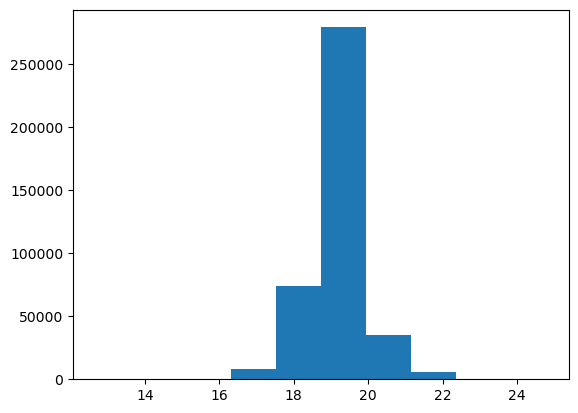

In [201]:
plt.hist(df_total['mag'][df_total['band']=='r'])

(<Figure size 1100x500 with 1 Axes>,
 <Axes: title={'center': 'OBJID = 1384147 (band color; legend by survey)'}, xlabel='MJD', ylabel='mag + offset'>)

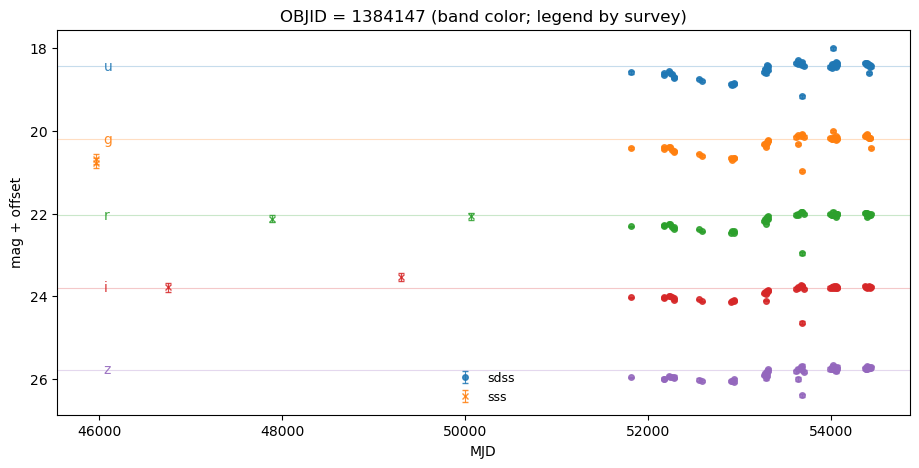

In [207]:
plot_lightcurve_by_objid(df_total, objid="1384147")

## SF

In [214]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ensemble_structure_function_per_band(
    df,
    obj_col="OBJID",
    band_col="band",
    t_col="time",
    mag_col="mag",
    err_col="magerr",
    z_col="z",
    bands=("u", "g", "r", "i", "z"),
    use_rest_frame=True,
    nbins=15,
    min_pairs_per_bin=20,
    ax=None,
    label_prefix="",
):
    """
    Compute ensemble (non-parametric) SF per band and plot all bands on one axis.
    Uses Press-style estimator: SF^2 = <(Δm)^2 - (σ_i^2+σ_j^2)>, clipped at 0.

    Returns
    -------
    sf_by_band : dict[str, pandas.DataFrame]
        Each DataFrame has columns: lag, sf, sf_err, npairs
    ax : matplotlib.axes.Axes
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))

    # Make sure band is normalized
    d0 = df.copy()
    d0[band_col] = d0[band_col].astype(str).str.lower()
    d0[obj_col] = d0[obj_col].astype(str)

    have_z = (z_col in d0.columns)
    if use_rest_frame and not have_z:
        # silently fall back (common case for df_total)
        use_rest_frame = False

    # Matplotlib default cycle (no hard-coded colors)
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if len(cycle) == 0:
        cycle = ["C0", "C1", "C2", "C3", "C4"]

    sf_by_band = {}

    for i, b in enumerate(bands):
        db = d0[d0[band_col] == b].copy()
        if len(db) == 0:
            continue

        dt_list = []
        val_list = []

        # group by object
        needed = [obj_col, t_col, mag_col, err_col]
        if use_rest_frame:
            needed.append(z_col)

        for oid, g in db.groupby(obj_col):
            g = g.dropna(subset=needed)
            if len(g) < 2:
                continue

            t = pd.to_numeric(g[t_col], errors="coerce").to_numpy()
            y = pd.to_numeric(g[mag_col], errors="coerce").to_numpy()
            sy = pd.to_numeric(g[err_col], errors="coerce").to_numpy()

            good = np.isfinite(t) & np.isfinite(y) & np.isfinite(sy)
            if good.sum() < 2:
                continue
            t, y, sy = t[good], y[good], sy[good]

            # (upper-triangle) pairwise differences
            dt_obs = t[:, None] - t[None, :]
            dy = y[:, None] - y[None, :]
            sig2 = sy[:, None]**2 + sy[None, :]**2
            sig2 = sig2*0.

            iu = np.triu_indices(len(t), k=1)
            dt = np.abs(dt_obs[iu])
            if use_rest_frame:
                z = float(pd.to_numeric(g[z_col].iloc[0], errors="coerce"))
                if not np.isfinite(z):
                    continue
                dt = dt / (1.0 + z)

            dy2 = dy[iu]**2
            sig2_pair = sig2[iu]

            dt_list.append(dt)
            val_list.append(dy2 - sig2_pair)

        if not dt_list:
            continue

        dt_all = np.concatenate(dt_list)
        val_all = np.concatenate(val_list)

        # keep positive lags and finite values
        m = (dt_all > 0) & np.isfinite(dt_all) & np.isfinite(val_all)
        dt_all = dt_all[m]
        val_all = val_all[m]
        if len(dt_all) == 0:
            continue

        # log-spaced bins
        dt_min, dt_max = float(dt_all.min()), float(dt_all.max())
        dt_min = 1e-3
        if not (dt_min > 0 and dt_max > dt_min):
            continue

        lag_bins = np.logspace(np.log10(dt_min), np.log10(dt_max), nbins + 1)
        lag_centers = np.sqrt(lag_bins[:-1] * lag_bins[1:])

        sf = np.full(nbins, np.nan)
        sf_err = np.full(nbins, np.nan)
        npairs = np.zeros(nbins, dtype=int)

        for k in range(nbins):
            in_bin = (dt_all >= lag_bins[k]) & (dt_all < lag_bins[k + 1])
            n = int(in_bin.sum())
            if n < min_pairs_per_bin:
                continue

            vals = val_all[in_bin]
            npairs[k] = n

            sf2 = float(np.mean(vals))
            sf2 = max(sf2, 0.0)
            sf[k] = np.sqrt(sf2)

            err_sf2 = float(np.std(vals)) / np.sqrt(n)
            sf_err[k] = 0.5 * err_sf2 / sf[k] if sf[k] > 0 else np.nan

        sf_df = pd.DataFrame(
            {"lag": lag_centers, "sf": sf, "sf_err": sf_err, "npairs": npairs}
        ).dropna(subset=["sf"])

        if len(sf_df) == 0:
            continue

        sf_by_band[b] = sf_df

        color = cycle[i % len(cycle)]
        ax.errorbar(
            sf_df["lag"],
            sf_df["sf"],
            yerr=sf_df["sf_err"],
            fmt="o",
            capsize=3,
            label=f"{label_prefix}{b}",
            color=color,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Lag $\Delta t$ (days)" + (r" (rest-frame)" if use_rest_frame else r" (observed-frame)"))
    ax.set_ylabel(r"Ensemble SF$(\Delta t)$ (mag)")
    ax.legend(frameon=False, title="band")
    ax.grid(False)
    ax.set_ylim(0.01, 1.0)

    return sf_by_band, ax


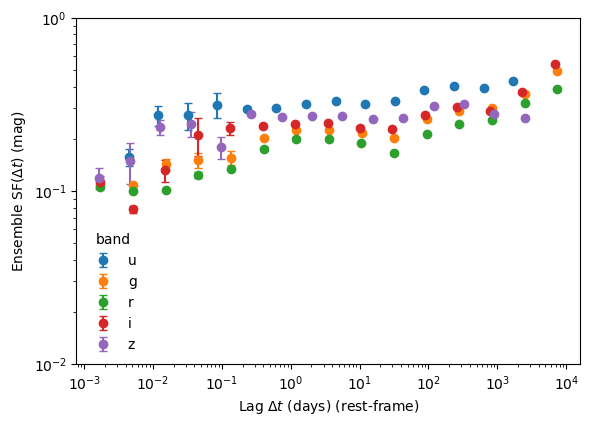

In [215]:
sf_by_band, ax = ensemble_structure_function_per_band(
    df_total,
    use_rest_frame=True,
    z_col="z",
)
plt.show()